In [1]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.insert(0,homepath)

%load_ext autoreload 
%autoreload 2


In [2]:
import gemmi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import reciprocalspaceship as rs
from meteor import rsmap
from meteor.sfcalc import gemmi_structure_to_calculated_map
from configuration import load_homepath
from configuration import get_file_config
from logger import setup_logger
%load_ext autoreload
%autoreload 2
logger = setup_logger()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
base = load_homepath() + "X8_runs/"
!ls $base

2025-05-08_16h29_Xtrapol8_661da1be-89ea-4d61-a4bd-dd6482a8049e.log
2026-01-09_18h24_Xtrapol8_7e3082ca-f8a7-48a5-92d0-a13ee5d8fc5a.log
2026-01-09_18h25_Xtrapol8_1b21ad6e-31f8-4206-80f9-0d20ca22316e.log
2026-01-09_18h26_Xtrapol8_9b76b0ba-1e14-447b-83a8-2cb5e9b90ec7.log
2026-01-09_18h27_Xtrapol8_58e097b3-352b-4255-893d-2204bda07855.log
2026-01-12_12h17_Xtrapol8_080a5703-dcda-4b35-847c-59890a3a46aa.log
2026-01-12_12h37_Xtrapol8_f759e98d-41c7-4fa4-a128-305eb5715341.log
2026-01-12_12h40_Xtrapol8_5bdaade1-17b3-4ed1-8ee3-fd750b23deb1.log
2026-01-12_16h45_Xtrapol8_c151ed49-9fef-4c56-98e2-136e59991a0e.log
2026-01-12_17h02_Xtrapol8_cf08512f-7433-473d-8b65-acea34f018c9.log
2026-01-19_10h10_Xtrapol8_e08605a2-8161-49dd-8bac-1f4c6c5108eb.log
2026-01-19_10h24_Xtrapol8_ab49e4e5-327a-4567-a589-d64d5615510b.log
2026-01-20_15h48_Xtrapol8_97162376-4387-418a-aef3-528428e80bdb.log
X8_test
X8_test_1
X8_test_1_1
X8_test_1_2
X8_test_2
X8_test_2_1
X8_test_3
X8_test_3_1
Xtrapol8
Xtrapol8_1
Xtrapol8_snr10.phil
cre

In [23]:
from alternative_methods import find_folder
# X8_path = load_homepath() + "X8_runs/gaussian_snr_10/"
# X8_path = load_homepath() + "X8_runs/qgaussian_snr_25/"
# X8_path = load_homepath() + "X8_runs/qsnr_10/"
# X8_path = load_homepath() + "X8_runs/qsnr_25/"
# X8_path = load_homepath() + "X8_runs/qsnr_100/"
# X8_path = load_homepath() + "X8_runs/snr_10/"
# X8_path = load_homepath() + "X8_runs/snr_25/"
# X8_path = load_homepath() + "X8_runs/snr_100/"
folder_conds = (
    # dict( noise_type = "gaussian", snr = 7, weight = ""),
    # dict( noise_type = "gaussian_flat", snr = 15, weight = ""),
    # dict( noise_type = "gaussian", snr = 10, weight = ""),
    # dict( noise_type = "gaussian", snr = 25, weight = ""),
    # dict( noise_type = "gaussian", snr = 5, weight = "q"),
    # dict( noise_type = "gaussian", snr = 10, weight = "q"),
    # dict( noise_type = "gaussian", snr = 25, weight = "q"),
    # dict( noise_type = "gaussian", snr = 100, weight = "q"),

    # dict( noise_type = "pseudo_poisson", snr = 10, weight = "q"),
    # dict( noise_type = "pseudo_poisson", snr = 25, weight = "q"),
    # dict( noise_type = "pseudo_poisson", snr = 100, weight = "q"),

    dict( noise_type = "pseudo_poisson", snr = 10, weight = ""),
    # dict( noise_type = "pseudo_poisson", snr = 25, weight = ""),
    dict( noise_type = "pseudo_poisson", snr = 100, weight = ""),
)
folder_cond =(
    dict( noise_type = "gaussian", snr = 7, weight = ""),
)
idx = 0
folder_cond = folder_conds[idx]
dark_name, diffmap_filename, folder_name, diffmap_columns, x8_analysis_snip = find_folder(folder_cond)
X8_path = load_homepath() +"X8_runs/" + folder_name
reference_mtz = load_homepath()  + "synthetic_cistrans/" + dark_name
diffmap_path = X8_path + diffmap_filename
xtrapolate_pickle = X8_path + x8_analysis_snip + ".pickle"
xtrapolate_plot = X8_path + x8_analysis_snip + ".png"

print(diffmap_path)
print(reference_mtz)

/Users/sbielfel/Nextcloud2/time_resolved/X8_runs/snr_10/xx_mFoFo.mtz
/Users/sbielfel/Nextcloud2/time_resolved/synthetic_cistrans/trans_snr_10_dmin_16.mtz


In [24]:
from alternative_methods import load_xtrapol8_data
reference_pdb = load_homepath() + "/synthetic_cistrans/trans.pdb"
dmin = 1.6
name_machine = "sim_rsEFGP2"

col_dict = {
    "amplitude_column": "F_on",
    "phase_column": "PHIC",
    "uncertainty_column": "SIGF_on",
}
config = get_file_config(
    reference_mtz,
    "",
    reference_pdb,
    col_dict,
    col_dict,
    name_machine = name_machine,
)

config["diffmap_path"] = diffmap_path
config["masking"]["exclude_large_occupancy_outliers"]= False
config["masking"]["dark_size_threshold"]= -1

ds_dark = rs.read_mtz(reference_mtz)
struc_dark = gemmi.read_pdb(reference_pdb)
map_dark_comp = gemmi_structure_to_calculated_map(
    struc_dark, high_resolution_limit=dmin,
)
ds_dark["PHIC"] = map_dark_comp.phases

try: 
    map_dark = rsmap.Map(ds_dark, amplitude_column="F_on", phase_column="PHIC")
    map_dark.loc[(0,0,0), "F_on"] = map_dark_comp.loc[(0,0,0), "F"]
    map_dark.loc[(0,0,0), "PHIC"] = 0
except KeyError:
    print("Not an 'on' dataset.")
    map_dark = rsmap.Map(ds_dark, amplitude_column="F", phase_column="PHIC")
    map_dark.loc[(0,0,0), "F"] = map_dark_comp.loc[(0,0,0), "F"]
    map_dark.loc[(0,0,0), "PHIC"] = 0
ds_diff = rs.read_mtz(diffmap_path)
diffmap = rsmap.Map(ds_diff, **diffmap_columns)

map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)

data = load_xtrapol8_data(xtrapolate_pickle)


/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_30353/50284632.py:34: PerformanceWarning: indexing past lexsort depth may impact performance.
  map_dark.loc[(0,0,0), "PHIC"] = 0


2026-03-10 16:15:28,270: logger: WARNING: Used threshold for posmask: 0.066, found 322 blobs (masking.py:133)
2026-03-10 16:15:28,280: logger: INFO: Using blobs with more than 22.00452891919375(3 A^3) voxels (masking.py:150)
2026-03-10 16:15:28,281: logger: INFO: Maximum Blob sizes found: 522 (masking.py:151)
2026-03-10 16:15:28,335: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-03-10 16:15:28,496: logger: INFO: Excluding 861 (38.64%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-03-10 16:15:28,521: logger: INFO: Excluding an addtional 0 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:268)
2026-03-10 16:15:28,543: logger: WARNING: Excluding an addt

saving to  /Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/all_methods_pseudo_poisson_snr10.png


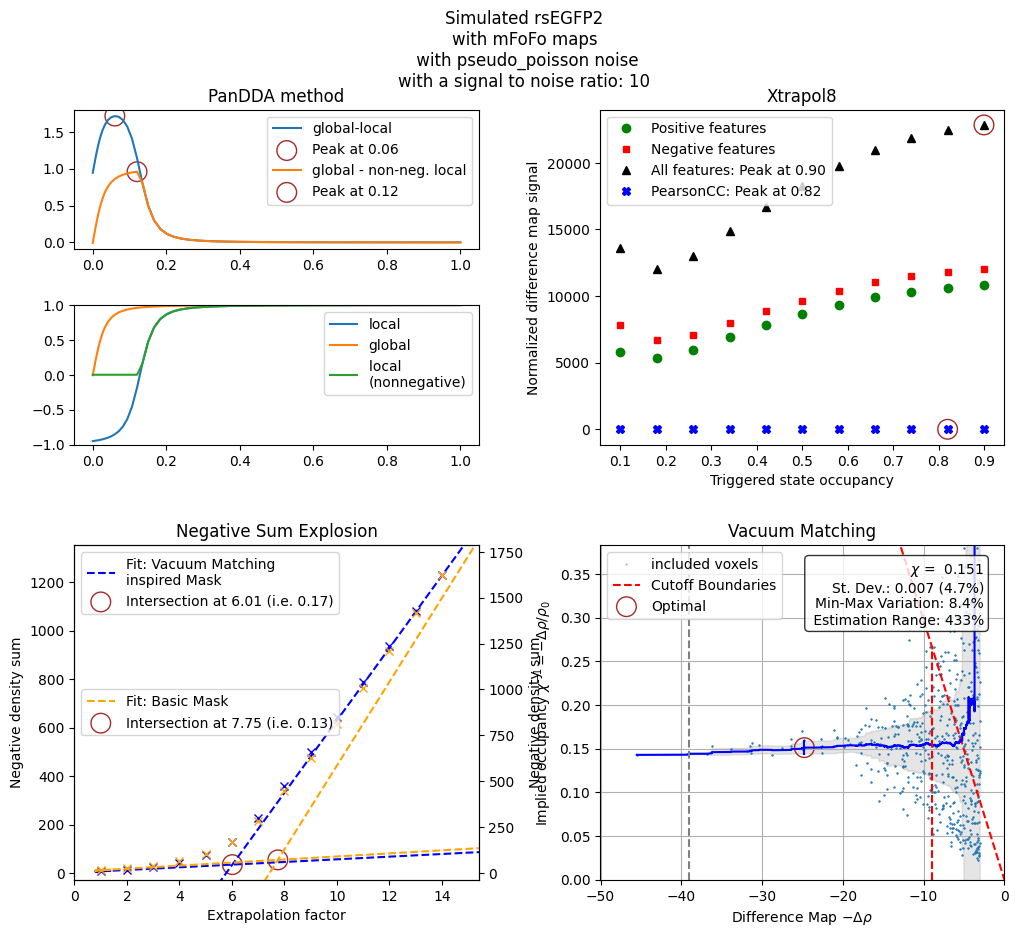

In [25]:
from configuration import load_figurepath
from masking import make_inclusion_mask
from estimation import plot_extrapolation_estimate_new
from alternative_methods import plot_pandda_results, _calculate_pandda
from alternative_methods import replot_xtrapol8
from alternative_methods import nse_analysis
from configuration import minimal_masking_config
import copy

inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
config_nse = copy.deepcopy(config)
config_nse["masking"] = minimal_masking_config()
inclusion_mask_nse = make_inclusion_mask(diffmap, map_dark, config_nse)

# 1. Create the main figure
fig = plt.figure(figsize=(12, 10))
title = "Simulated rsEGFP2\n"
title += f"with {folder_cond['weight']}mFoFo maps"
title += f"\n with {folder_cond['noise_type']} noise"
title += f"\nwith a signal to noise ratio: {folder_cond['snr']}"
fig.suptitle(title, fontsize=12)

# 2. Define the 2x2 outer grid
outer_grid = fig.add_gridspec(2, 2, wspace=0.3, hspace=0.3)

# ------------------------ Cell (0,0): The "Double Plot" -----------------------
# We split this specific cell into 2 rows and 1 column
inner_grid = outer_grid[0, 0].subgridspec(2, 1, hspace=0.4)
ax0_top = fig.add_subplot(inner_grid[0, 0])
ax0_bottom = fig.add_subplot(inner_grid[1, 0])
ax_pandda= [ax0_top, ax0_bottom]

pandda_dict = _calculate_pandda(diffmap_np, map_dark_np, inclusion_mask)
alpha = 0.13
_ = plot_pandda_results(pandda_dict, axs = ax_pandda, improved=True)

# --------------------------- Cell (0,1): Plot 2 --------------------------- 
ax1 = fig.add_subplot(outer_grid[0, 1])
replot_xtrapol8(data, axes=ax1)
ax1.set_title("Xtrapol8")

# --------------------------- Cell (1,0): Plot 3 ---------------------------
ax2 = fig.add_subplot(outer_grid[1, 0])
figargs=dict(title="Basic Mask", color="orange")
ax2_twin = ax2.twinx()
nse_analysis(diffmap, map_dark, inclusion_mask_nse, figargs=figargs, ax=ax2_twin)
figargs=dict(title="Vacuum Matching \ninspired Mask", color="blue", legend=True)
nse_analysis(diffmap, map_dark, inclusion_mask, figargs=figargs, ax=ax2, )
ax2.set_title("Negative Sum Explosion")

# --------------------------- Cell (1,1): Plot 4 ---------------------------
ax3 = fig.add_subplot(outer_grid[1, 1])
plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask_nse, config, ax3)
ax3.set_title("Vacuum Matching")
# ax3.set_xlim(0,1)
# ax3.set_ylim(0,0.81)


loc = load_figurepath()
name = f"all_methods{folder_cond['weight']}_{folder_cond['noise_type']}_snr{folder_cond['snr']}.png"
fileloc = loc + name
print('saving to ', fileloc)
fig.savefig(fileloc)

plt.show()

In [7]:
len(map_dark.spacegroup.operations())

4

In [8]:
import matplotlib.pyplot as plt
from masking import make_inclusion_mask
from estimation import plot_extrapolation_estimate

inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# np.argsort(diffmap_np*inclusion_mask)[:np.sum(inclusion_mask.astype(int))]

# fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
# ax.axvline(0.13)
# ax.axvline(0.26)
# ax.set_xlim(0,.58)
# plt.show()

2026-03-06 10:49:58,418: logger: WARNING: Used threshold for posmask: 0.066, found 322 blobs (masking.py:133)
2026-03-06 10:49:58,422: logger: INFO: Using blobs with more than 22.00452891919375(3 A^3) voxels (masking.py:150)
2026-03-06 10:49:58,422: logger: INFO: Maximum Blob sizes found: 522 (masking.py:151)
2026-03-06 10:49:58,468: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-03-06 10:49:58,651: logger: INFO: Excluding 861 (38.64%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-03-06 10:49:58,678: logger: INFO: Excluding an addtional 0 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:268)
2026-03-06 10:49:58,701: logger: WARNING: Excluding an addt

[np.int64(169), np.int64(169), np.int64(108652)]
[0.15095855 0.15095863 0.15095855 0.15095855 0.15362968 0.15362969
 0.15362966 0.15362974 0.15536572 0.15536568]


/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_37862/737707100.py:4: RuntimeWarning: divide by zero encountered in divide
  pseudo = -(diffmap_np/map_dark_np).flatten()


Text(0, 0.5, 'Difference Map Value')

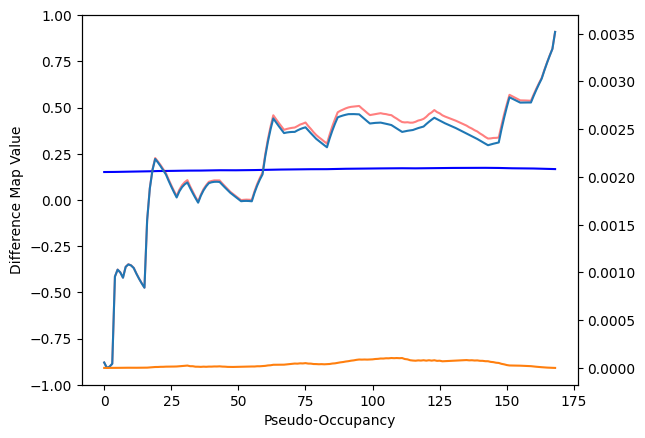

In [9]:
only_large_dark = map_dark_np > map_dark_np.mean() + 2*map_dark_np.std()
inclusion_2 = np.logical_and(only_large_dark, inclusion_mask)
print([np.sum(m) for m in [inclusion_2, inclusion_mask, only_large_dark]])
pseudo = -(diffmap_np/map_dark_np).flatten()
main_mask = inclusion_2
diff = (-diffmap_np*main_mask).flatten()
number_sym_ops = 1 # for rsEGFP2
leng_shown = np.sum(main_mask)
argsorted = np.argsort(diff)[::-number_sym_ops][:leng_shown]
print(pseudo[argsorted][:10])

pseudo_sort = np.cumsum(pseudo[argsorted]) / (np.arange(len(argsorted))+1)
# 1. Your existing sorted data
sorted_vals = pseudo[argsorted]
cum_mean = np.cumsum(sorted_vals) / (np.arange(len(sorted_vals)) + 1)
cum_mean_sq = np.cumsum(sorted_vals**2) / (np.arange(len(sorted_vals)) + 1)

# 4. Cumulative standard deviation
# We use np.maximum to avoid tiny negative numbers due to floating point error
cum_std = np.sqrt(np.maximum(cum_mean_sq - cum_mean**2, 0))
pseudo_std = cum_std
pseudo_ste = pseudo_std/np.sqrt(np.arange(1,len(argsorted)+1))*2
bias_term = [(pseudo_sort[i] - pseudo_sort[i//2])**2 for i in range(len(pseudo_sort))]

# ax.plot(diff[argsorted],pseudo_sort, label='Cumulative Pseudo-Occupancy', color='blue')
fig, ax = plt.subplots()
ax.plot(pseudo_sort, label='Cumulative Pseudo-Occupancy', color='blue')
# ax.fill_between(np.arange(len(pseudo_ste)), pseudo_sort - pseudo_ste, pseudo_sort + pseudo_ste, color='blue', alpha=0.2)
# ax.fill_between(np.arange(len(pseudo_ste)), pseudo_sort - pseudo_ste, pseudo_sort - pseudo_ste-bias_term, color='green', alpha=0.2)
# ax.fill_between(np.arange(len(pseudo_ste)), pseudo_sort + pseudo_ste, pseudo_sort + pseudo_ste+bias_term, color='green', alpha=0.2)
# ax.set_ylim(0,0.3)
ax.set_ylim(-1,1)
ax2 = ax.twinx()
ax2.plot(pseudo_ste+bias_term, label='Cumulative Pseudo-Occupancy', color='red', alpha=0.5)
ax2.plot(pseudo_ste, label='Cumulative Pseudo-Occupancy',)
ax2.plot(bias_term, label='Cumulative Pseudo-Occupancy', )
# ax2.plot(diff[argsorted], label='Cumulative Pseudo-Occupancy', color='green', alpha=0.5)
ax.set_xlabel("Pseudo-Occupancy")
ax.set_ylabel("Difference Map Value")


In [36]:
import gemmi
from masking import support_from_masker
from processing import autoshift_rsmap


from copy import deepcopy

def prepper( map_dark, diffmap_np, cutoff_threshold, config, inclusion_mask=None):
    map_dark_shifted, dark_offset = autoshift_rsmap(deepcopy(map_dark), config["general"])
    print("dark_offset", dark_offset)


    dark_map_array = map_dark_shifted.to_3d_numpy_map(
        map_sampling=config["general"]["map_sampling"]
    )
    print("map dark mean", dark_map_array.mean())

    no_inclusion_mask = inclusion_mask is None
    if no_inclusion_mask:
        inclusion_mask = np.ones(dark_map_array.shape, dtype=bool)
    cutoff_dark = dark_map_array.mean() + cutoff_threshold * dark_map_array.std()
    only_large_dark = dark_map_array > cutoff_dark
    inclusion_2 = np.logical_and(only_large_dark, inclusion_mask)
    if not no_inclusion_mask:
        print(
            "share excluded from inclusion mask:",
            1 - 1 / np.sum(inclusion_mask) * np.sum(inclusion_2),
        )
    pseudo = -(diffmap_np / dark_map_array).flatten()
    main_mask = inclusion_2
    diff = (-diffmap_np * main_mask).flatten()
    print("map dark mean", dark_map_array.mean())
    return pseudo, diff, cutoff_dark

def cummean_and_errors(pseudo, diff2, leng_shown=None, number_sym_ops=1):
    leng_shown = len(diff2) if leng_shown is None else leng_shown
    argsorted = np.argsort(diff2)[::-number_sym_ops][:leng_shown]
    pseudo_sort = np.cumsum(pseudo[argsorted]) / (np.arange(len(argsorted))+1)
    # 1. Your existing sorted data
    sorted_vals = pseudo[argsorted]
    cum_mean = np.cumsum(sorted_vals) / (np.arange(len(sorted_vals)) + 1)
    cum_mean_sq = np.cumsum(sorted_vals**2) / (np.arange(len(sorted_vals)) + 1)

    # 4. Cumulative standard deviation
    # We use np.maximum to avoid tiny negative numbers due to floating point error
    cum_std = np.sqrt(np.maximum(cum_mean_sq - cum_mean**2, 0))
    pseudo_std = cum_std
    pseudo_ste = pseudo_std/np.sqrt(np.arange(1,len(argsorted)+1))*2
    bias_term = [np.abs(pseudo_sort[i] - pseudo_sort[i//2]) for i in range(len(pseudo_sort))]
    return {
        "pseudo_sort": pseudo_sort,
        "pseudo_ste": pseudo_ste,
        "bias_term": bias_term,
        "diff_sorted": diff2[argsorted],
        "pseudo_std": pseudo_std
    }

def make_plot(
    cummean_dict,
    cutoff_dark,
    x_axis_type= "voxel_count", # "diff_value"
    add_noise_plots=False,
):
    pseudo_sort, pseudo_ste, bias_term, diff_sorted, pseudo_std = (
        cummean_dict["pseudo_sort"],
        cummean_dict["pseudo_ste"],
        cummean_dict["bias_term"],
        cummean_dict["diff_sorted"],
        cummean_dict["pseudo_std"],
    )
    if x_axis_type == "voxel_count":
        x_axis_values = np.arange(len(pseudo_sort))
        xlabel = "# Voxels"
    elif x_axis_type == "diff_value":   
        x_axis_values = -diff_sorted
        xlabel = "Diffmap Values"
    else:
        raise ValueError(f"Unknown x_axis_type: {x_axis_type}")

    cutoffline_indexed = diff_sorted/cutoff_dark
    cutoffline_indexed = diff_sorted/cutoff_dark
    max_pseudo = np.max(pseudo_sort + pseudo_std)
    print("Max Pseudo:", max_pseudo)
    cutoffline_below = cutoffline_indexed < max_pseudo
    # cutoffline_above = ~cutoffline_below
    idx = np.argmax(cutoffline_below)
    left, bottom, width, height = (np.min(x_axis_values), 0., np.abs(x_axis_values[idx]-np.min(x_axis_values)), max_pseudo)
    left = float(left)
    print(left, bottom, width, height, idx, (pseudo_sort + pseudo_ste)[idx])
    
    rect = plt.Rectangle((left, bottom), width, height,
                        facecolor="black", alpha=0.1)

    if add_noise_plots:
        fig, axs = plt.subplots(1,2, figsize=(12,6))
        ax, ax2 = axs
        ax2.plot(x_axis_values, pseudo_ste, label='Pseudo Standard Error', color='red', alpha=0.5)
        ax2.plot(x_axis_values, bias_term, label='Bias Term: |F(N) -F(N/2)| ', color='orange', alpha=0.5)
        ax2.set_xlabel(xlabel)
        ax2.legend()

    else:
        fig, ax = plt.subplots(figsize=(6,6))
    ax.add_patch(rect)
    ax.fill_between(
        x_axis_values,
        pseudo_sort - pseudo_ste,
        pseudo_sort + pseudo_ste,
        color='blue',
        alpha=0.2,
    )
    pseudo_masked = pseudo_sort[idx//10:idx+1]
    pseudo_label = 'Cumulative Mean \nPseudo-Occupancy'
    pseudo_label += f'\nMean: {pseudo_sort[idx]:.4f}'
    pseudo_label += f'\nStandard Error: {pseudo_ste[idx]:.4f} ({pseudo_ste[idx]/pseudo_sort[idx]:.2%})'
    drift_error = pseudo_masked[0] - pseudo_masked[-1]
    pseudo_label += f'\nDrift Error: {drift_error:.4f} ({drift_error/pseudo_sort[idx]:.2%})'
    ax.plot(x_axis_values, pseudo_sort, label=pseudo_label, color='blue')
    ax.plot(x_axis_values, cutoffline_indexed, label='Diffmap / Cutoff_dark', color='red', )
    # ax.plot(x_axis_values[cutoffline_below], cutoffline_indexed[cutoffline_below], label='Diffmap / Cutoff_dark(below)', color='orange', alpha=0.5)
    # ax.plot(x_axis_values[cutoffline_above], cutoffline_indexed[cutoffline_above], label='Diffmap / Cutoff_dark(above)', color='orange', alpha=0.5)

    # axi = ax2.twinx()
        # ax2.set_yscale('log')
    ax.set_ylabel("Pseudo-Occupancy")
    ax.set_xlabel(xlabel)
    ax.legend()
    ax.set_ylim(0,None)
    print(np.sign(x_axis_values[1]))
    limit = [0,None] if x_axis_values[1]>=0 else [None,0]
    ax.set_xlim(limit)
    ax.grid()
    # ax.set_ylim(0,0.2)
    title = "Cumulative Mean Pseudo-Occupancy with Errors"
    fig.suptitle(title)
    return fig, ax
    # # ax.set_title(f"Dataset {i}")




Max Pseudo: 0.2437920908163097
0.0 0.0 824 0.2437920908163097 824 0.18741796633090713
1
Max Pseudo: 0.2437920908163097
-0.5405442118644714 0.0 0.45449454 0.2437920908163097 824 0.18741796633090713
-1.0


/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_8096/3554111146.py:7: RuntimeWarning: divide by zero encountered in divide
  pseudo = -(diffmap_np / map_dark_np).flatten()


Text(0.5, 0.98, 'Cutoff Threshold: 1 sigma')

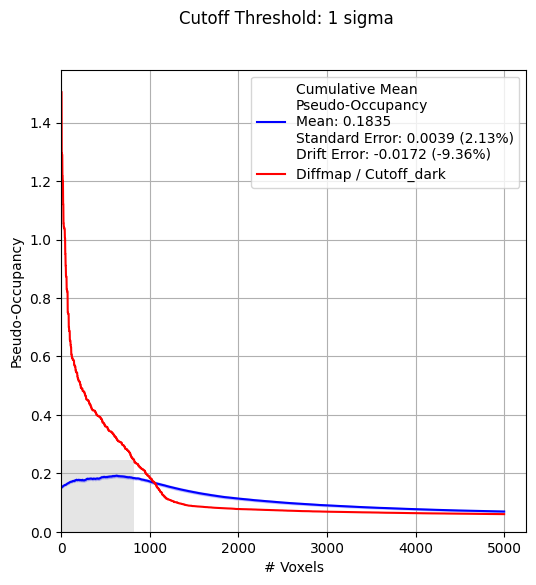

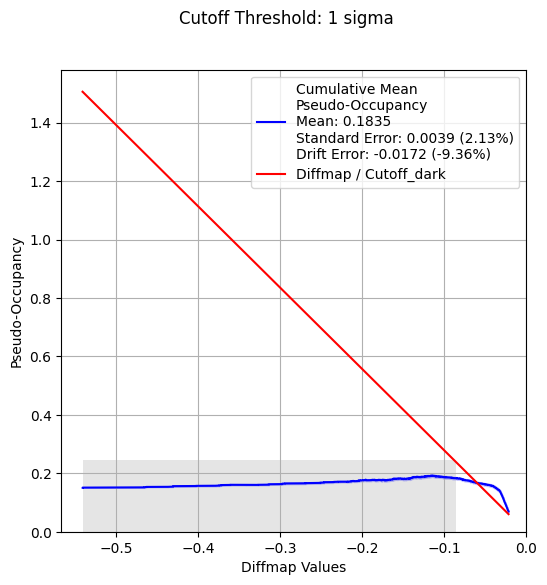

In [ ]:
leng_shown = 5000

cutoff_threshold = 1
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
cutoff_dark = map_dark_np.mean() + cutoff_threshold * map_dark_np.std()
only_large_dark = map_dark_np > cutoff_dark
pseudo = -(diffmap_np / map_dark_np).flatten()
main_mask = only_large_dark
diff = (-diffmap_np * main_mask).flatten()
cummean_dict = cummean_and_errors(pseudo, diff, leng_shown=leng_shown, number_sym_ops=1)
fig, ax = make_plot(cummean_dict, cutoff_dark, x_axis_type="voxel_count")
fig.suptitle(f"Cutoff Threshold: {cutoff_threshold} sigma")
fig, ax = make_plot(cummean_dict, cutoff_dark, x_axis_type="diff_value")
fig.suptitle(f"Cutoff Threshold: {cutoff_threshold} sigma")


2026-02-17 18:39:42,065: logger: WARNING: Mean of diffmap_np: -5.518948579391614e-12, Mean of map_dark_np: 0.022628869861364365 (2344484158.py:12)


168 0.07959609
168 0.08790004
168 0.09620399
168 0.104507945
168 0.11281189
164 0.12111585
164 0.1294198
160 0.13772376
160 0.14602771
160 0.15433165
156 0.16263561
156 0.17093956
144 0.17924352
140 0.18754748
136 0.19585142
132 0.20415537
128 0.21245933
112 0.22076328
108 0.22906724
96 0.23737118
96 0.24567513
84 0.2539791
84 0.26228303
72 0.270587
72 0.27889097
72 0.2871949
68 0.29549885
60 0.3038028
60 0.31210676
52 0.32041073
48 0.32871467
48 0.3370186
44 0.34532255
44 0.3536265
40 0.3619305
40 0.37023443
28 0.37853837
24 0.3868423
24 0.39514625
20 0.40345025
20 0.4117542
20 0.42005813
20 0.42836207
16 0.436666
12 0.44497
12 0.45327395
12 0.4615779
4 0.46988183
4 0.47818583
4 0.48648977


/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/estimation.py:32: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np


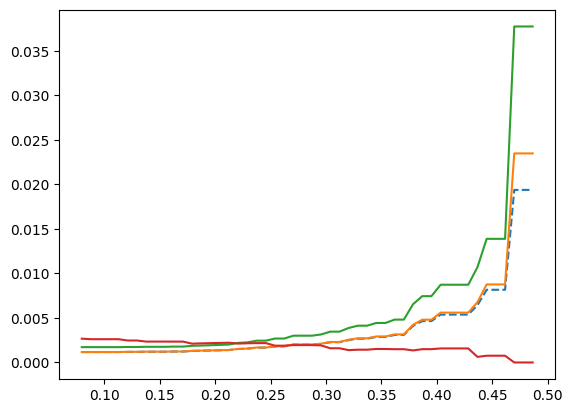

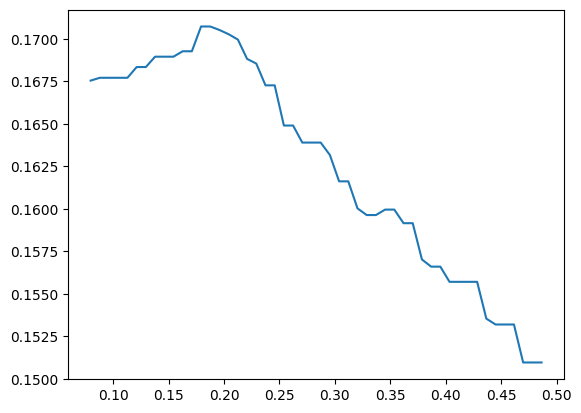

In [38]:
from estimation import _calculate_statistics, _analyze_threshold_trends
maxlen = inclusion_mask.sum()
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
sigma = np.std(map_dark_np)
idcs = np.argsort(((diffmap_np*inclusion_mask).flatten()))[:maxlen]
cumsum = np.cumsum(map_dark_np.flatten()[idcs])

general_config = config["general"]

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=general_config["map_sampling"])
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=general_config["map_sampling"])
logger.warning(
    f"Mean of diffmap_np: {np.mean(diffmap_np)}, Mean of map_dark_np: {np.mean(map_dark_np)}"
)
stats_data = _calculate_statistics(diffmap_np, map_dark_np, inclusion_mask)
trend_data = _analyze_threshold_trends(
    stats_data["diffmap_masked"],
    stats_data["pseudo_occupancy"],
    stats_data["weight"],
)
collect_idx = []
collect_vals = []
for jj,thresh in enumerate(trend_data["threshold"]):
    idx = np.sum(- stats_data["diffmap_masked"] >thresh)
    mask = - stats_data["diffmap_masked"] >thresh

    print(idx, thresh)
    collect_idx.append((idx))
    collect_val = sigma/np.sum(map_dark_np[inclusion_mask][mask])
    collect_vals.append(collect_val)
plt.figure()
plt.plot(trend_data["threshold"], sigma/cumsum[np.array(collect_idx)], "--")
plt.plot(trend_data["threshold"], np.array(collect_vals), )
# plt.plot(trend_data["threshold"], trend_data["std"], )
plt.plot(trend_data["threshold"], trend_data["stability"], )
plt.plot(trend_data["threshold"], trend_data["std"]/ np.sqrt(trend_data["weight"]), )
plt.show()
# plt.figure()
# plt.plot(trend_data["threshold"], trend_data["std"]/ np.sqrt(trend_data["weight"]), )
plt.figure()
# plt.plot(trend_data["threshold"],  np.sqrt(trend_data["weight"]), )
# plt.plot(trend_data["threshold"], trend_data["bootstrap_mean"])
plt.plot(trend_data["threshold"], trend_data["mean"])
    


In [39]:
# from alternative_methods import plot_negative_density_trends, _calculate_negative_density_trends
# from alternative_methods import nse_analysis

# fig, ax = nse_analysis(diffmap, map_dark, inclusion_mask, )
# ax.set_xlim(0,10)

2026-02-18 16:05:47,221: logger: WARNING: Mean of diffmap_np: -5.518948579391614e-12, Mean of map_dark_np: 0.022628869861364365 (2823896877.py:13)
/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/estimation.py:32: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np


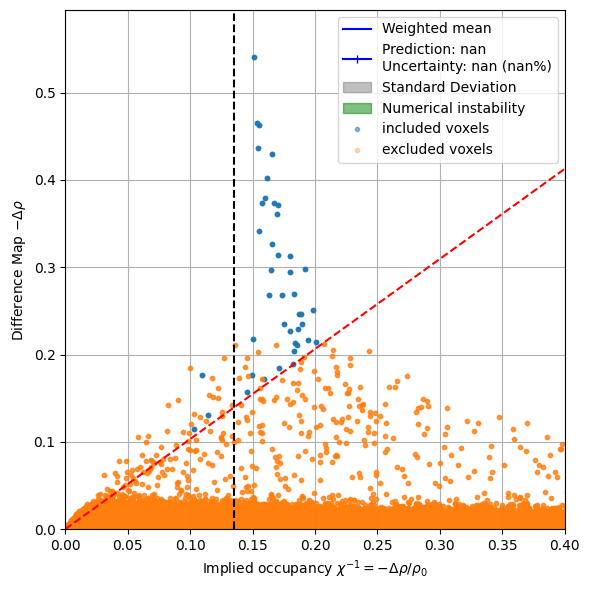

In [ ]:
# fig,ax3 = plt.subplots(1,2)
# plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config, ax3)
# ax3.plot
# ax3.set_title("Vacuum Matching")
# ax3.set_xlim(0,1)

from estimation import  _create_plot
general_config = config["general"]
config['masking']['dark_size_threshold']

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=general_config["map_sampling"])
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=general_config["map_sampling"])
logger.warning(
    f"Mean of diffmap_np: {np.mean(diffmap_np)}, Mean of map_dark_np: {np.mean(map_dark_np)}"
)
stats_data = _calculate_statistics(diffmap_np, map_dark_np, inclusion_mask)
trend_data = _analyze_threshold_trends(
    -stats_data["diffmap_masked"],
    stats_data["pseudo_occupancy"],
    stats_data["weight"],
)

# 5. Visualization
ax = None
fig, ax = _create_plot_v2(stats_data, trend_data, config["plot"], general_config, ax)
diffline = np.linspace(0, np.max(-stats_data["diffmap_masked"]), 100)
cutoff_dark = map_dark_np.mean()+ config['masking']['dark_size_threshold'] * map_dark_np.std()
ax.plot(diffline / cutoff_dark, diffline, 'r--', label='Dark Size Threshold')
ax.axvline(0.135, color='k', linestyle='--', label='Dark Size Threshold')
ax.set_xlim(0,0.4)
plt.show()

In [35]:
config['masking']['dark_size_threshold']

3

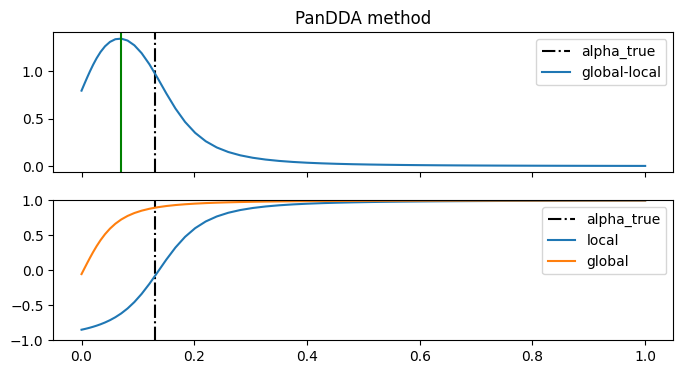

In [ ]:
# /Users/sbielfel/Nextcloud2/time_resolved/X8_runs/alternative_methods.py
from alternative_methods import plot_pandda_results, _calculate_pandda
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
pandda_dict = _calculate_pandda(diffmap_np, map_dark_np, inclusion_mask)
alpha = 0.13
fig, axs = plot_pandda_results(pandda_dict, alpha)

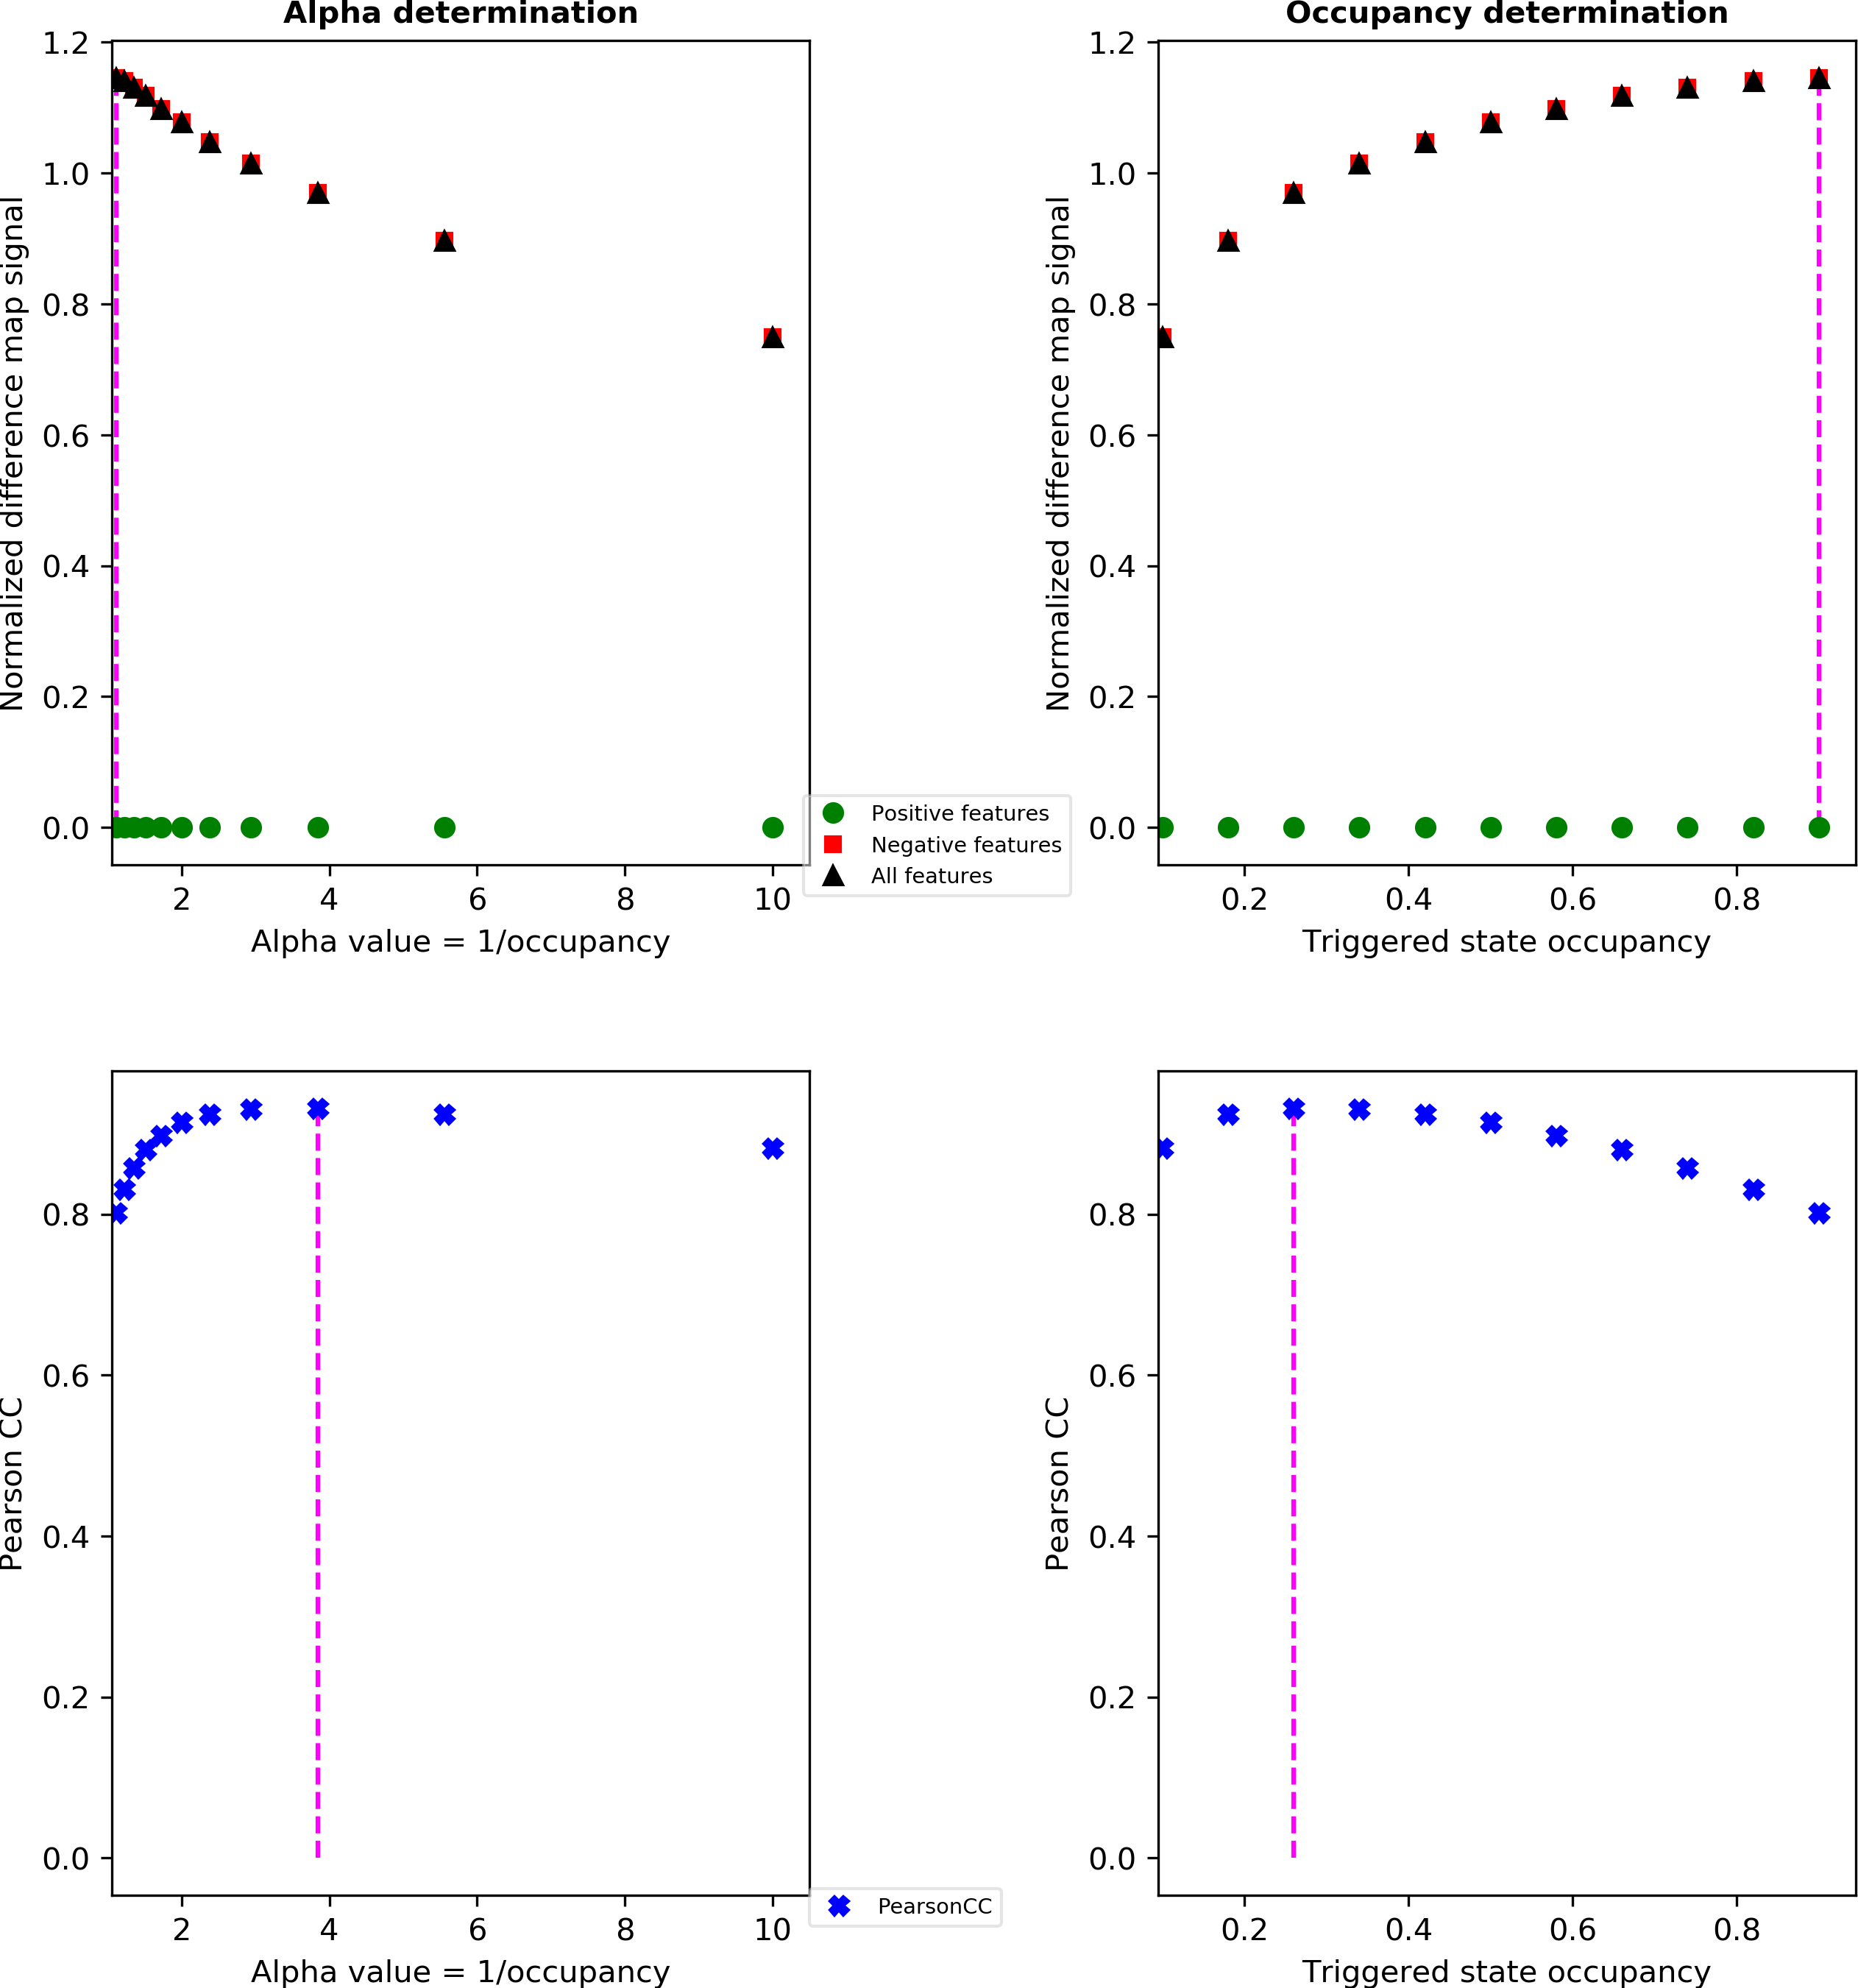

In [ ]:
from IPython.display import Image
xtrapolate_plot = X8_path + x8_analysis_path + ".png"
Image(filename=xtrapolate_plot, )
#Fxtr-Fc vs FoFo
#Fxtr = F_0^{comp/genick/obs} + X FoFo


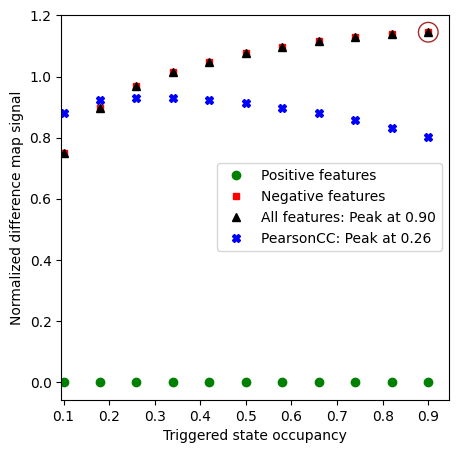

In [ ]:
_ = replot_xtrapol8(xtrapolate_pickle)

2026-01-14 18:50:04,675: logger: WARNING: Used threshold for posmask: 0.103, found 356 blobs (masking.py:133)
2026-01-14 18:50:04,679: logger: INFO: Using blobs with more than 22.00452891919375(3 A^3) voxels (masking.py:150)
2026-01-14 18:50:04,679: logger: INFO: Maximum Blob sizes found: 219 (masking.py:151)
2026-01-14 18:50:04,695: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-01-14 18:50:04,837: logger: INFO: Excluding 173 (11.91%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-01-14 18:50:04,862: logger: INFO: Excluding an addtional 0 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:267)
2026-01-14 18:50:04,880: logger: WARNING: Excluding an addt

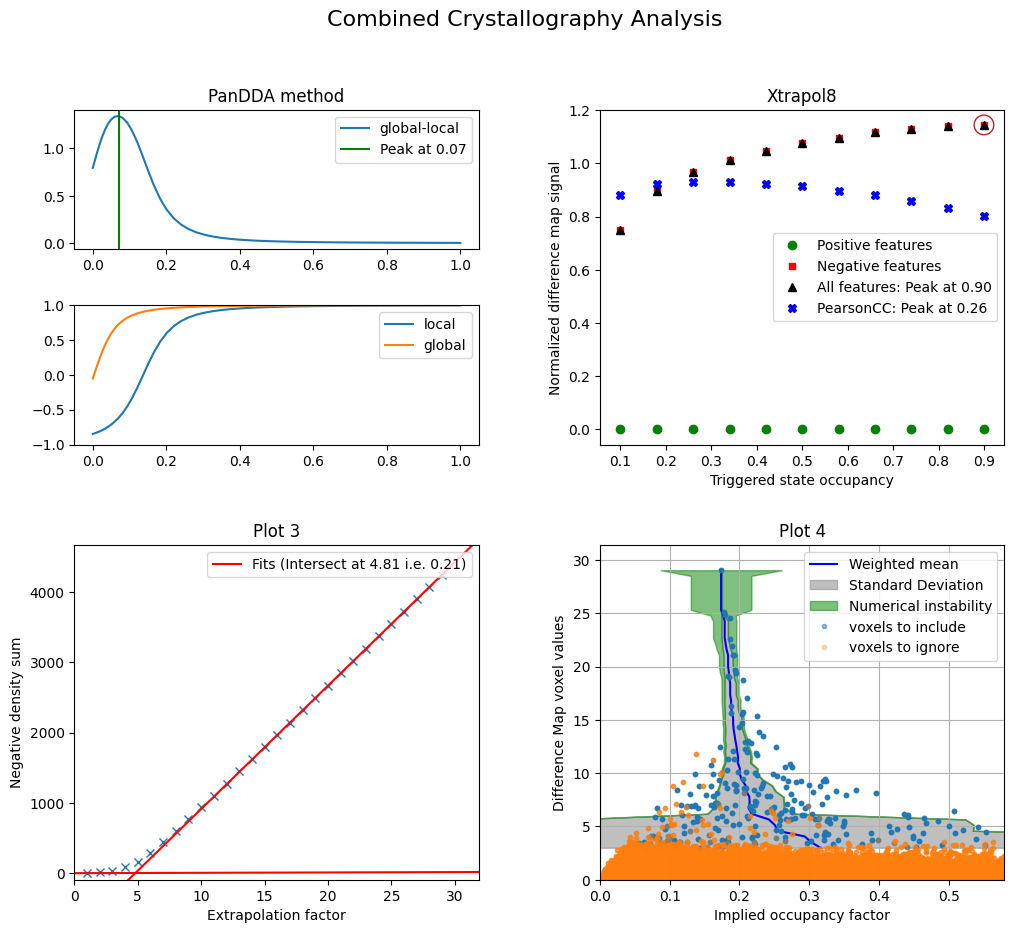